In [1]:
import pandas as pd

# Load data
df = pd.read_csv("D:\\New folder\\Cars_data (1).csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["price", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())


      price  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [2]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [3]:
# Drop rows with missing price
df.dropna(subset=["price"], inplace=True)

# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median())

0        12.99
1        15.10
2        18.53
3        15.80
4        24.52
         ...  
34028    17.42
34029    27.39
34030    18.60
34031    18.60
34032    21.21
Name: mileage_new, Length: 34033, dtype: float64

In [4]:
df["max_power"].fillna(df["max_power"].median())
df["max_torque"].fillna(df["max_torque"].median())

0        200.0
1        330.0
2        113.0
3        151.0
4        200.0
         ...  
34028    320.0
34029    190.0
34030    114.7
34031    114.7
34032    113.0
Name: max_torque, Length: 34033, dtype: float64

In [5]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

In [6]:
import numpy as np

# Define columns to check for outliers
log_cols = ['max_power', 'max_torque', 'max_engine_capacity_new', 'price']

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [7]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])


In [8]:
import numpy as np

features = [
    
 "km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new"

]

df = df.dropna(subset=["price"])
df = df.dropna(subset=features)
X = df[features]
y = df["price"]
#y = np.log(df["price"])  # Natural logarithm (base e)

In [9]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


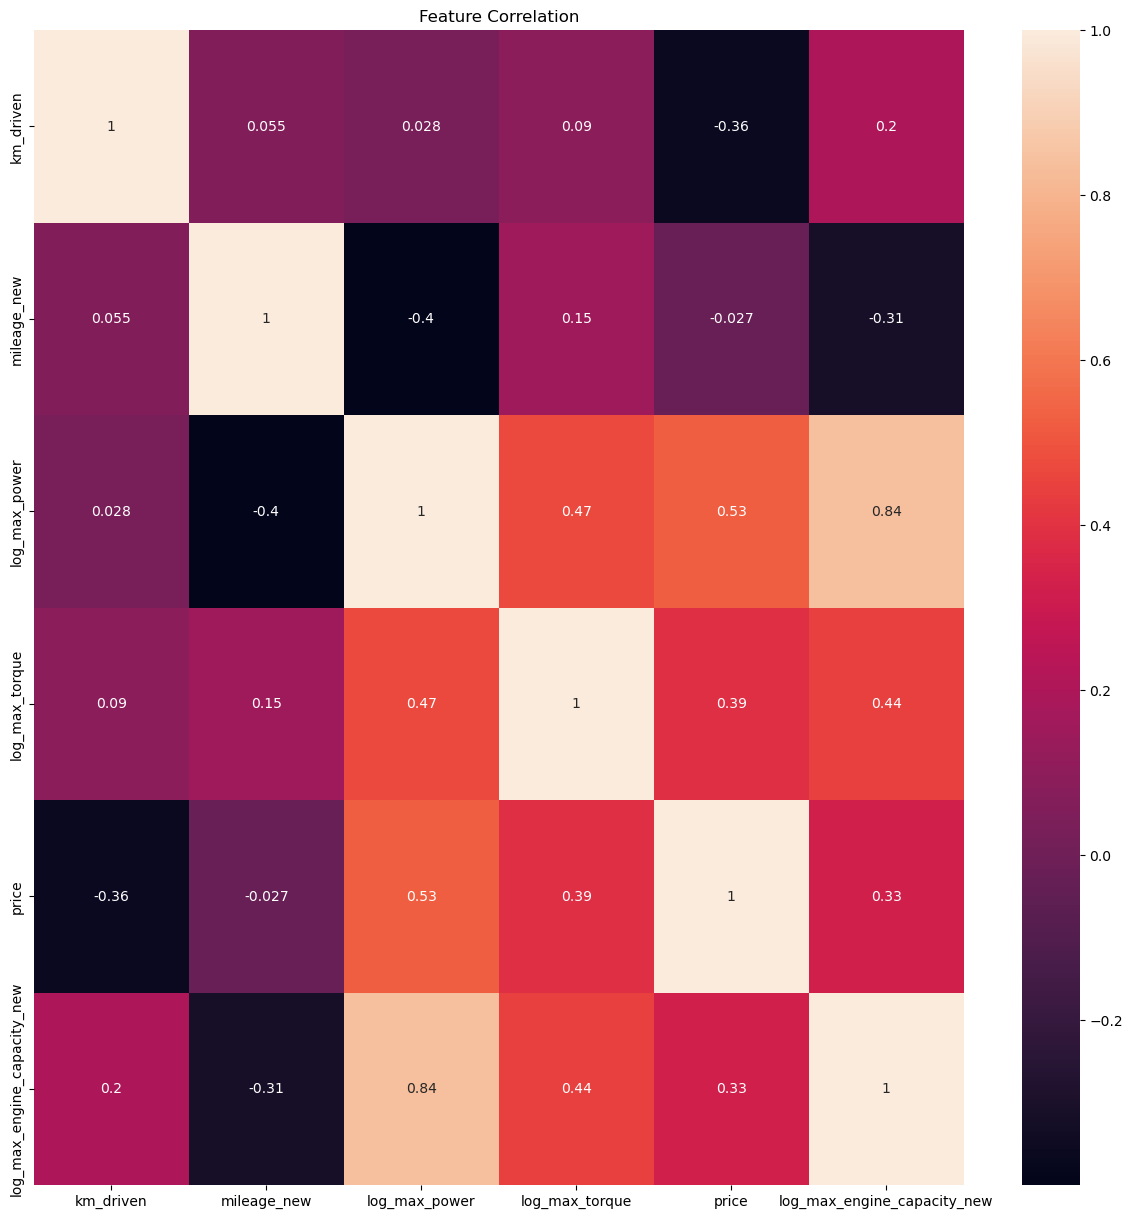

In [11]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(15, 15))

sns.heatmap(df[[
"km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

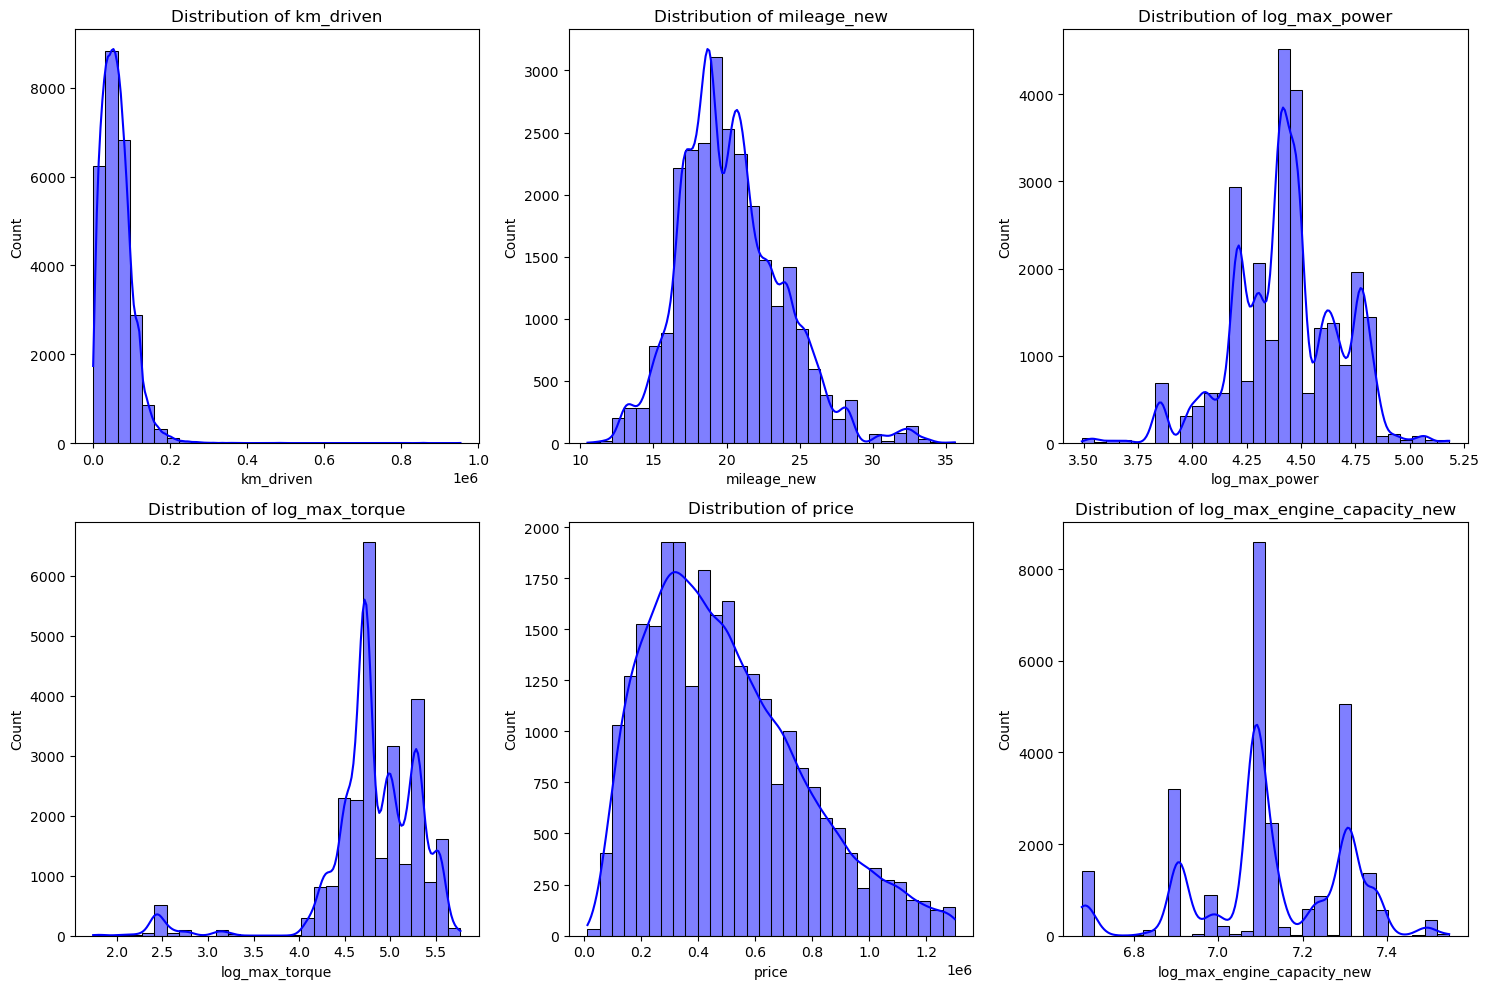

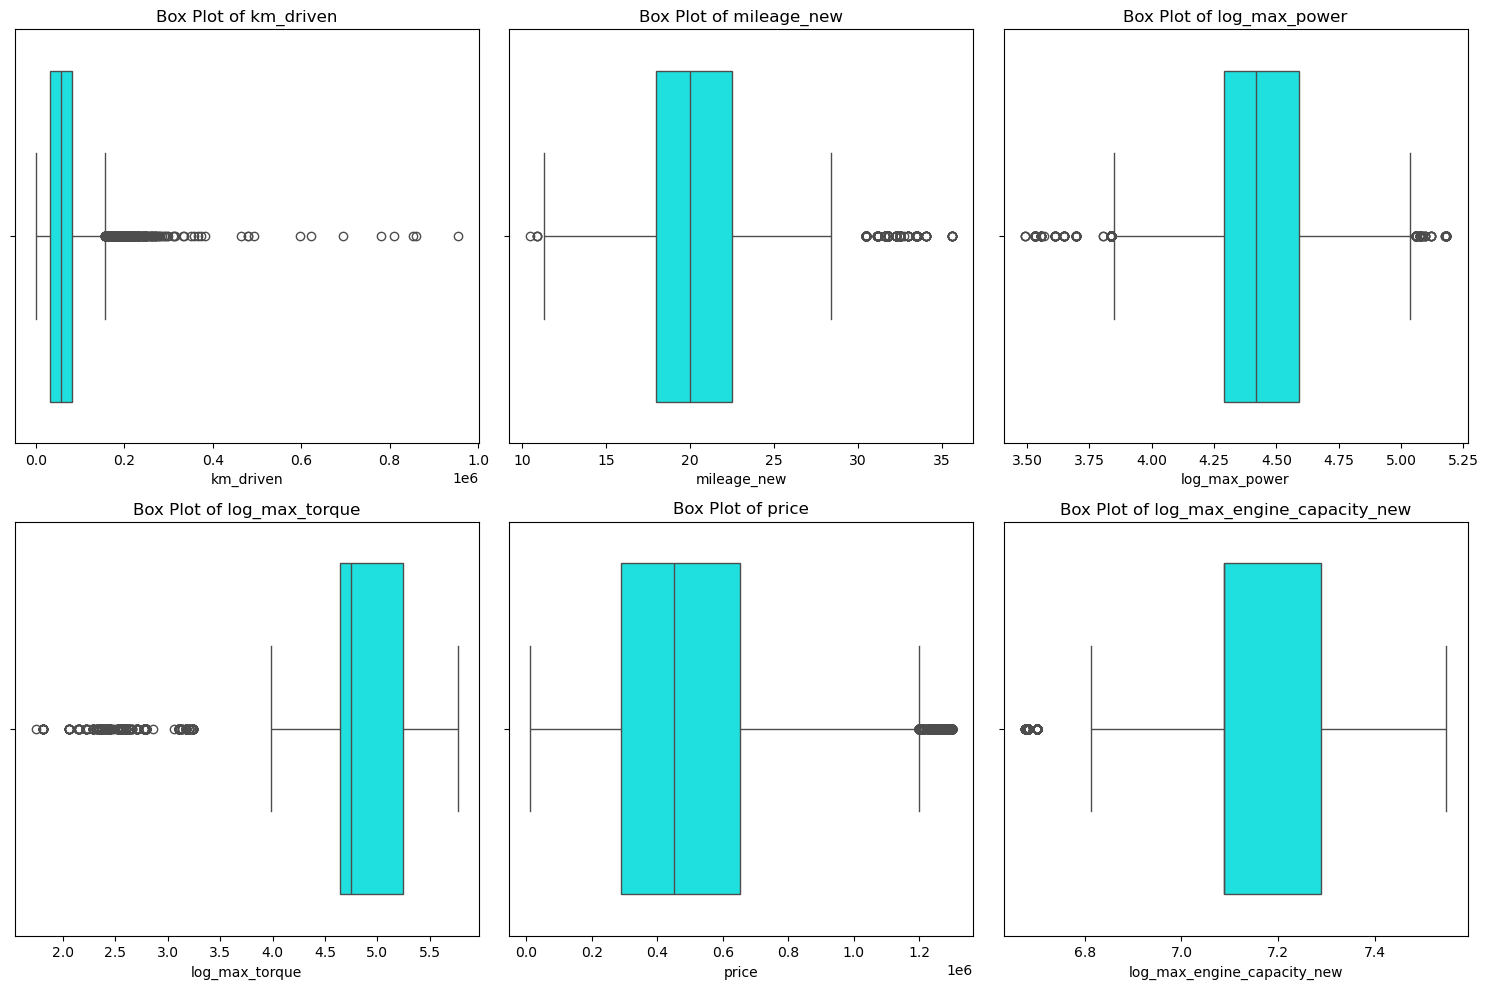

In [12]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model1 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model1.summary()
model1.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model1.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 315551645696.0000 - mae: 493926.9688 - val_loss: 300316917760.0000 - val_mae: 479782.2500
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 291623763968.0000 - mae: 470508.9375 - val_loss: 239041282048.0000 - val_mae: 415185.3750
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 216694292480.0000 - mae: 388668.7500 - val_loss: 121645539328.0000 - val_mae: 266697.4375
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 95347474432.0000 - mae: 233236.8594 - val_loss: 48305000448.0000 - val_mae: 176811.2188
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49060601856.0000 - mae: 178326.9062 - val_loss: 44723617792.0000 - val_mae: 171889.1250
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45519990784.0000 - mae: 173458.4844 - val_loss: 41187201024.0000 - val_mae: 165102.1875
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 41867804672.0000 - mae: 166226.4531 - val_loss

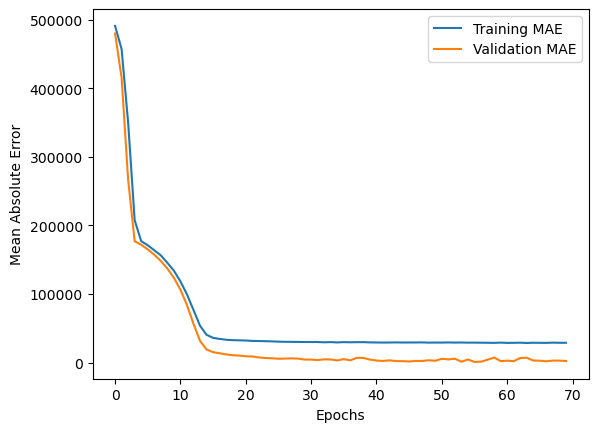

In [15]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

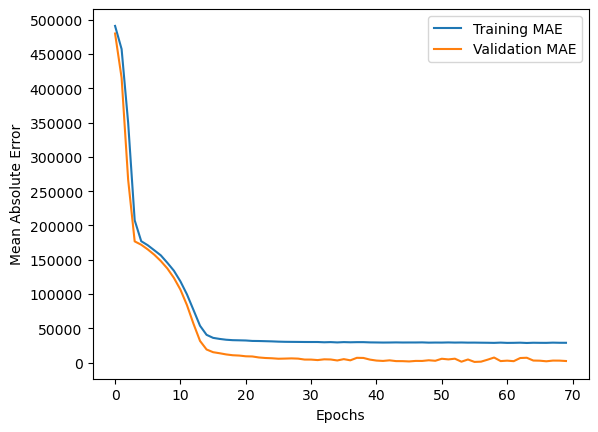

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model2 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model2.summary()
model2.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model2.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 310119301120.0000 - mae: 489173.1562 - val_loss: 259602432000.0000 - val_mae: 437876.8750
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 218569998336.0000 - mae: 388504.0625 - val_loss: 86005841920.0000 - val_mae: 219007.7031
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 69260926976.0000 - mae: 197964.2500 - val_loss: 47294881792.0000 - val_mae: 175240.3594
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 47578673152.0000 - mae: 176327.0469 - val_loss: 44619177984.0000 - val_mae: 171769.4062
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45095284736.0000 - mae: 172196.2031 - val_loss: 41837510656.0000 - val_mae: 166355.0781
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 42607824896.0000 - mae: 167130.8906 - val_loss: 38707298304.0000 - val_mae: 159698.7812
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 39321497600.0000 - mae: 160332.8594 - val_loss: 3

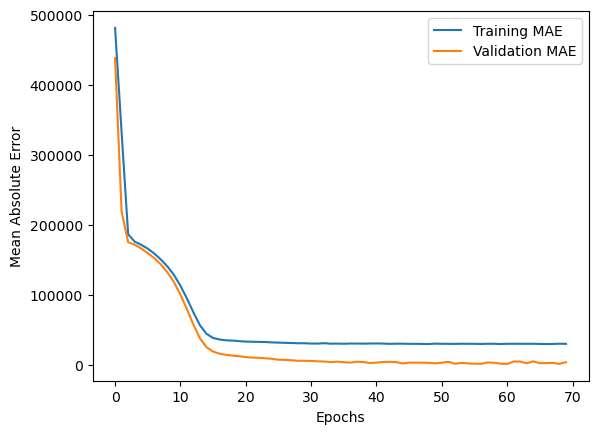

In [19]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

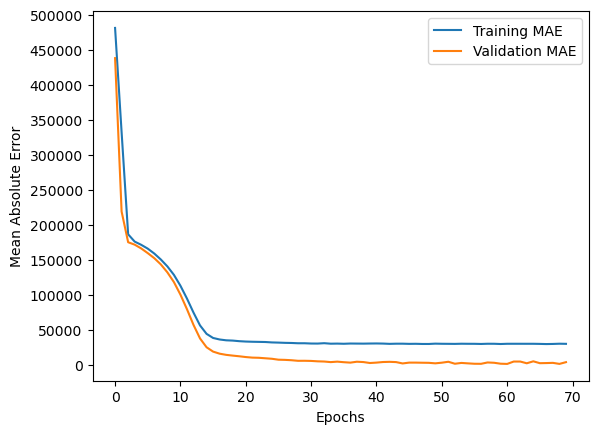

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model3 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.1),

    Dense(1)
])
model3.summary()
model3.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,729 (100.50 KB)

 Trainable params: 25,729 (100.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 248414830592.0000 - mae: 418435.3125 - val_loss: 43830456320.0000 - val_mae: 170224.7812
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 42607063040.0000 - mae: 167225.2969 - val_loss: 28242520064.0000 - val_mae: 135679.6094
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25176711168.0000 - mae: 126797.4922 - val_loss: 7243664896.0000 - val_mae: 68587.7266
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7445746688.0000 - mae: 66950.4219 - val_loss: 849067648.0000 - val_mae: 22073.6465
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3503391744.0000 - mae: 45313.1914 - val_loss: 493233760.0000 - val_mae: 16046.0850
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3036091392.0000 - mae: 41225.6875 - val_loss: 287356160.0000 - val_mae: 12294.7080
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2746144512.0000 - mae: 38777.8906 - val_loss: 228966032.0000 - val_m

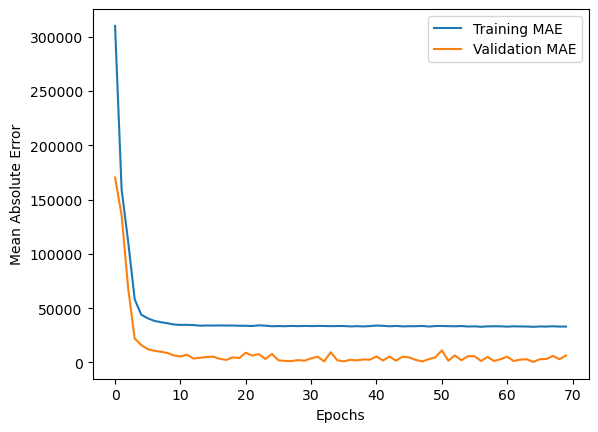

In [22]:
history = model3.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

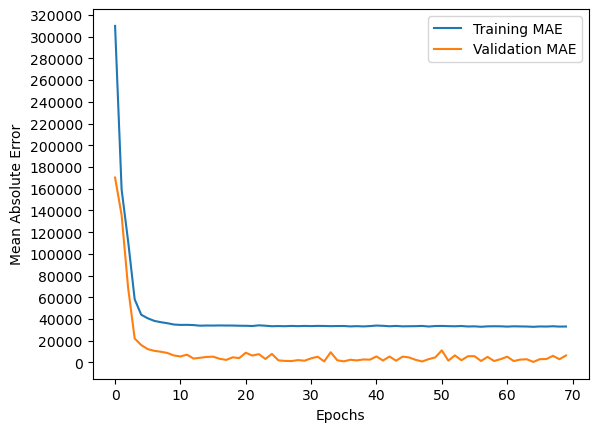

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model4 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(127, activation="relu"),
    Dropout(0.1),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model4.summary()
model4.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 127)            │        32,639 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 127)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,808 (686.75 KB)

 Trainable params: 175,808 (686.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 166106923008.0000 - mae: 313283.6562 - val_loss: 2054798080.0000 - val_mae: 35890.8906
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3017051392.0000 - mae: 41499.2539 - val_loss: 244166864.0000 - val_mae: 11669.4355
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2369345024.0000 - mae: 35271.4414 - val_loss: 416964448.0000 - val_mae: 17676.4922
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2172544768.0000 - mae: 33472.5469 - val_loss: 53757240.0000 - val_mae: 5699.4795
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2203107584.0000 - mae: 33507.4492 - val_loss: 13798784.0000 - val_mae: 2592.8838
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2176770816.0000 - mae: 33071.7148 - val_loss: 24680484.0000 - val_mae: 4200.3999
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2174267648.0000 - mae: 32866.5195 - val_loss: 16806632.0000 - val_mae: 3414.2637
Epo

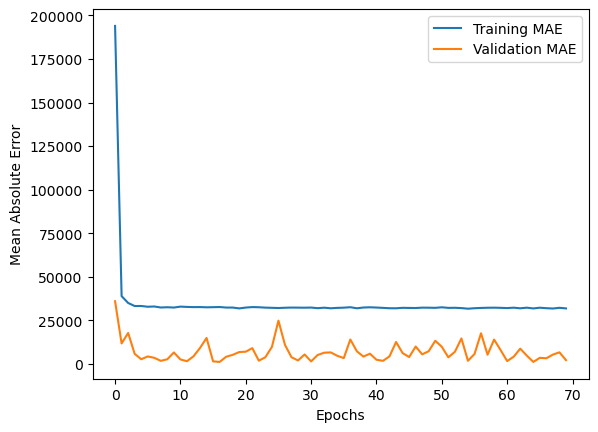

In [25]:
history = model4.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


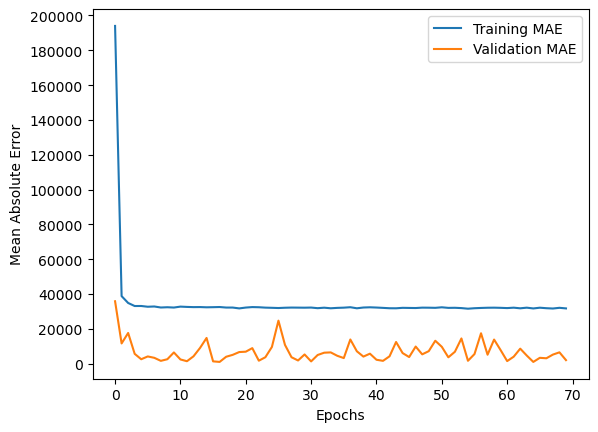

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model5 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(1)
])
model5.summary()
model5.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,481 (455.00 KB)

 Trainable params: 116,481 (455.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 156167684096.0000 - mae: 303490.7812 - val_loss: 790988160.0000 - val_mae: 21207.3184
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3596706816.0000 - mae: 43981.2734 - val_loss: 205549696.0000 - val_mae: 11843.3984
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3249526016.0000 - mae: 40558.1367 - val_loss: 285539040.0000 - val_mae: 15851.3018
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3051447808.0000 - mae: 39245.3789 - val_loss: 268046656.0000 - val_mae: 15704.8545
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3063684096.0000 - mae: 39703.2656 - val_loss: 38955516.0000 - val_mae: 5181.6665
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2937198592.0000 - mae: 38583.5703 - val_loss: 19260666.0000 - val_mae: 3414.0261
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2985456384.0000 - mae: 38765.3203 - val_loss: 28303388.0000 - val_mae: 3790.2954
Ep

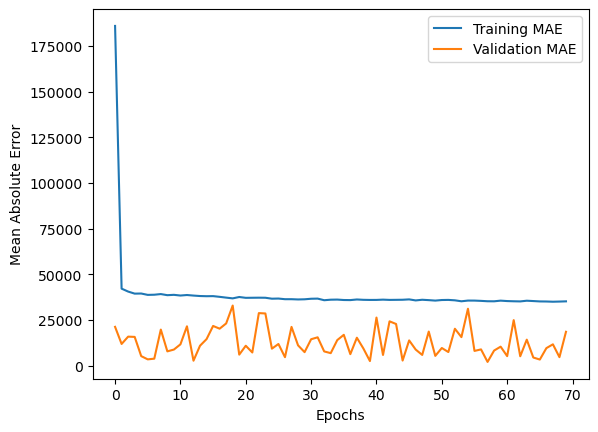

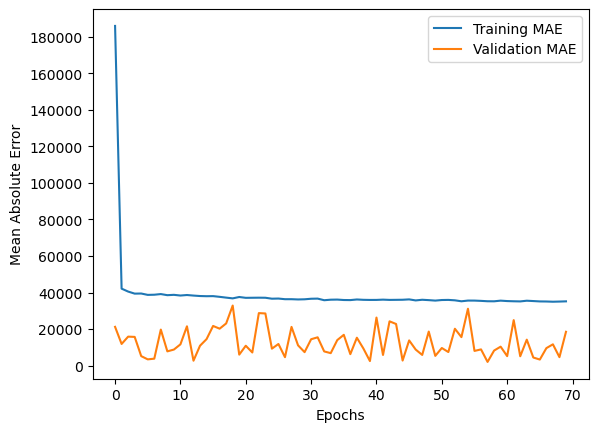

In [28]:

history = model5.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 287270633472.0000 - mae: 461583.2188 - val_loss: 46868242432.0000 - val_mae: 175562.2656
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 45493653504.0000 - mae: 171903.7656 - val_loss: 30526824448.0000 - val_mae: 142770.7500
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 27255959552.0000 - mae: 132320.3281 - val_loss: 5112321536.0000 - val_mae: 57651.3906
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4832619520.0000 - mae: 52937.2969 - val_loss: 346196192.0000 - val_mae: 13887.4580
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2783941632.0000 - mae: 38252.3242 - val_loss: 169289840.0000 - val_mae: 9602.2529
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2630978816.0000 - mae: 36882.6758 - val_loss: 184035632.0000 - val_mae: 10839.1582
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2629183232.0000 - mae: 36492.2539 - val_loss: 84867240.0000 - val_mae

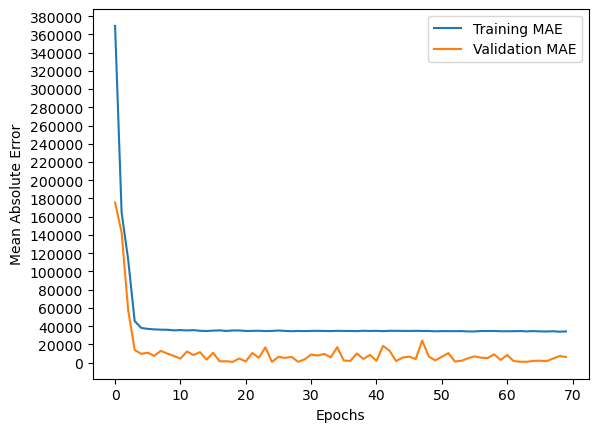

In [30]:
history = model6.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 280863506432.0000 - mae: 455887.3438 - val_loss: 47035756544.0000 - val_mae: 176580.6406
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45224976384.0000 - mae: 172713.0781 - val_loss: 30265380864.0000 - val_mae: 142531.5000
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 24985419776.0000 - mae: 127205.5000 - val_loss: 2678505984.0000 - val_mae: 41307.8438
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2984444672.0000 - mae: 41417.5312 - val_loss: 261977360.0000 - val_mae: 11797.0469
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2012537600.0000 - mae: 32840.0508 - val_loss: 218378160.0000 - val_mae: 11774.8301
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1861469184.0000 - mae: 30934.8320 - val_loss: 57858608.0000 - val_mae: 5648.2695
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1841497856.0000 - mae: 30417.6289 - val_loss: 43941016.0000 - val_mae:

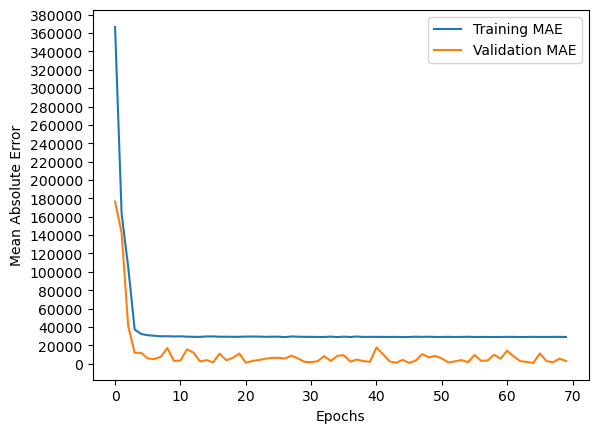

In [32]:
history = model6.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

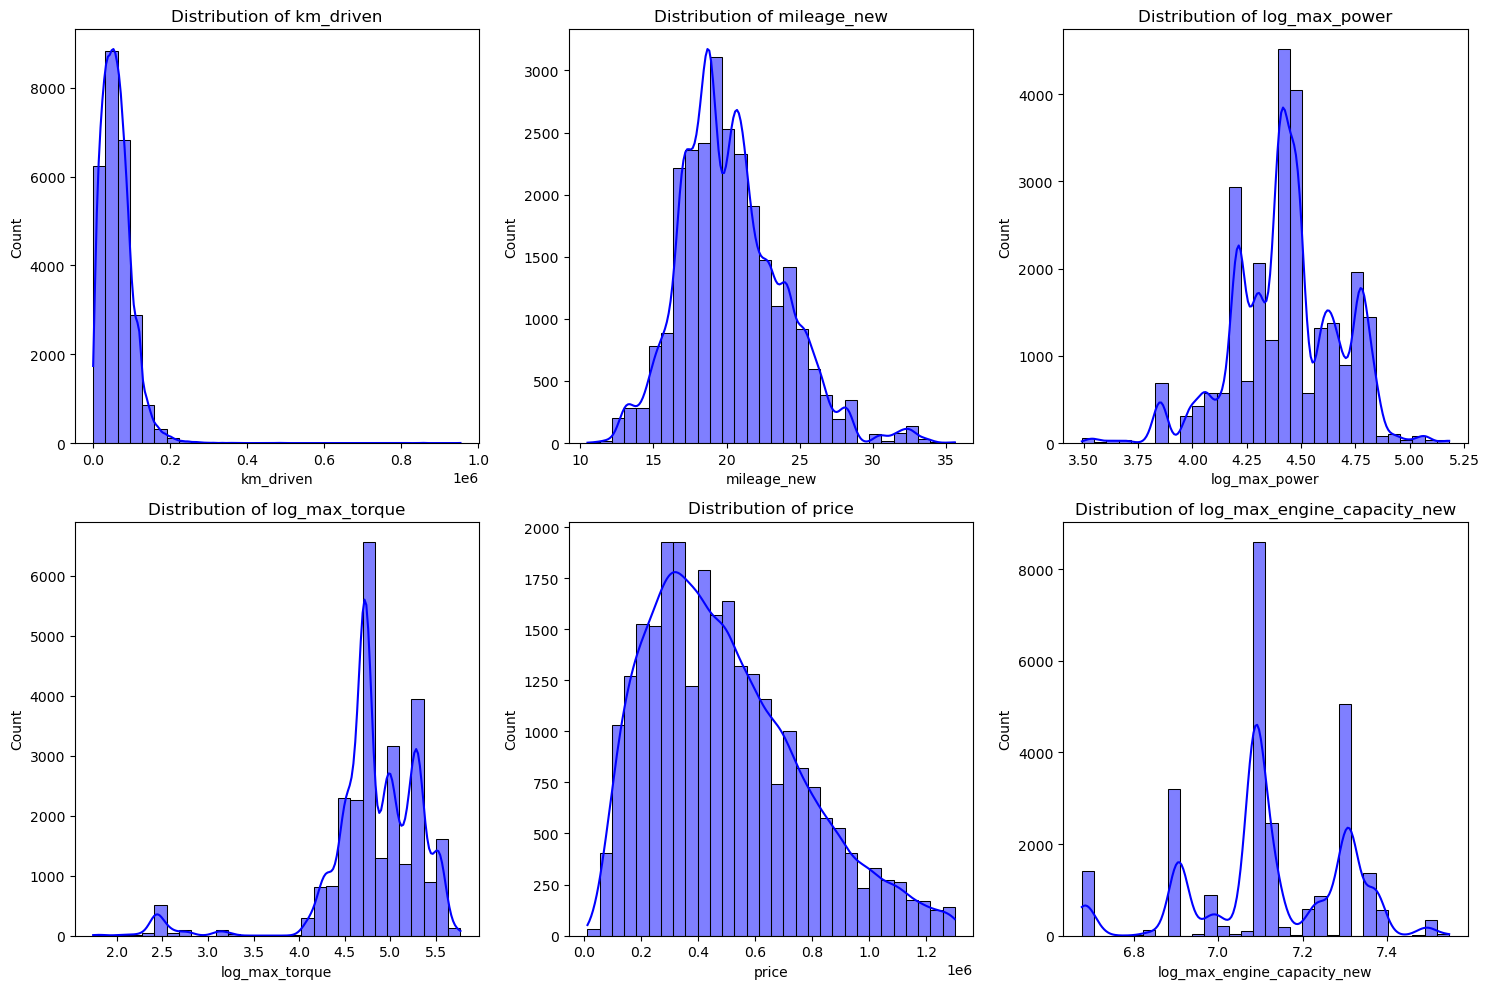

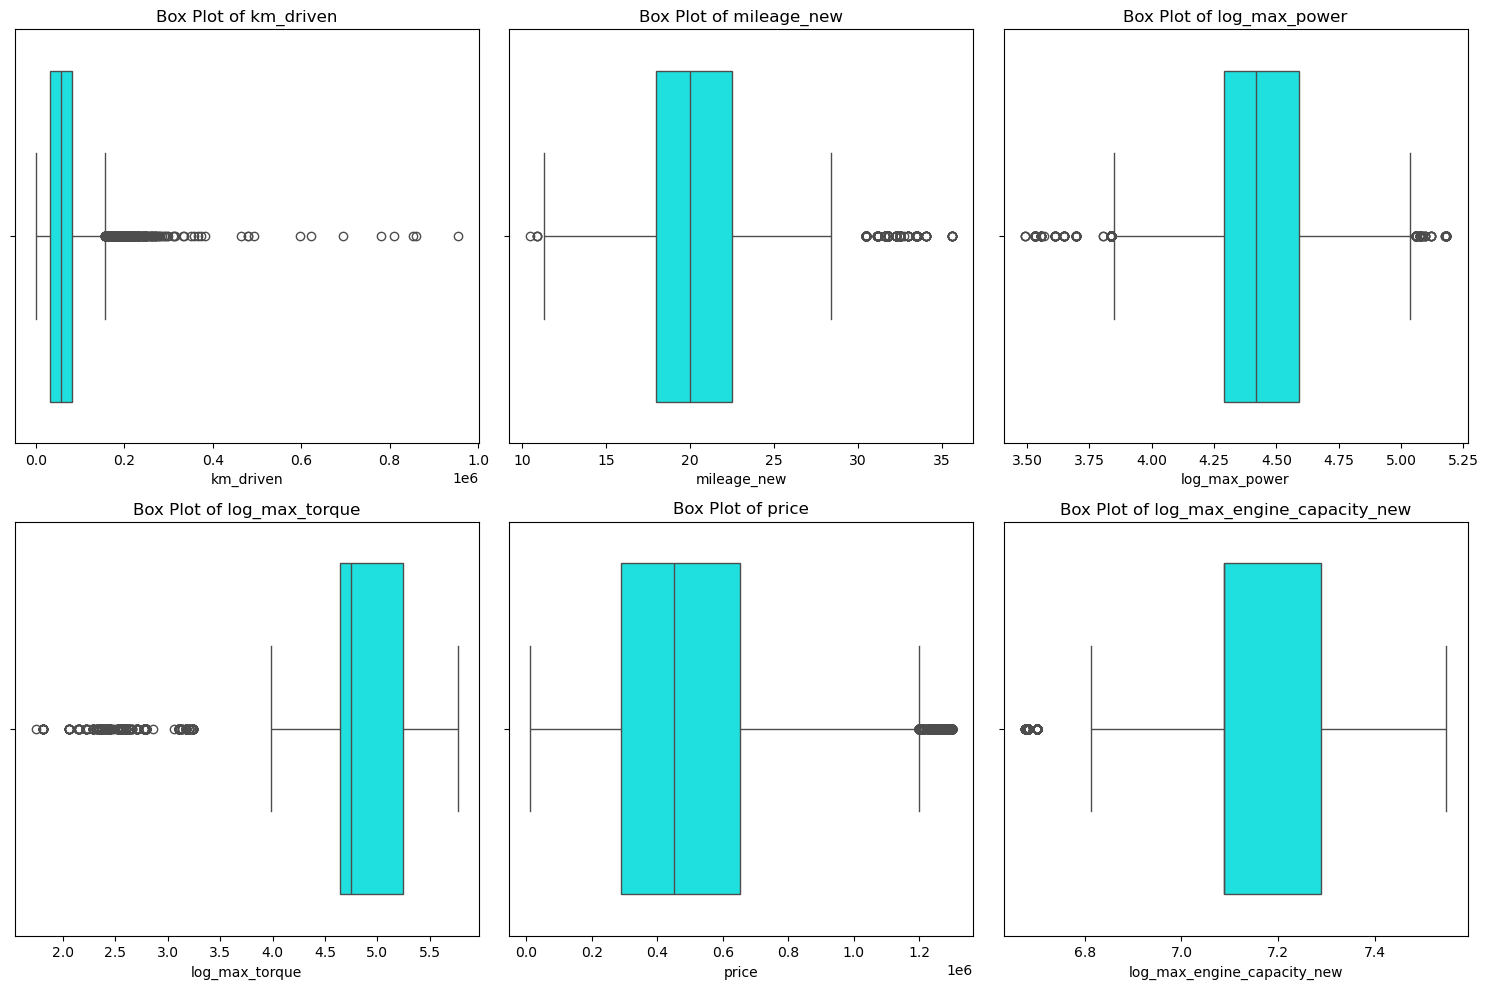

In [ ]:
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]



# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()